# Decision Tree Regression

## Setup & imports

In [1]:
# Standard imports
import pandas as pd
import numpy as np

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# For display & plots
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42


## Load dataset

In [ ]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## EDA

In [7]:
print(df.info())
print(df.describe(include='all').T)
print("Categorical value counts:")
print(df[['sex','smoker','region']].apply(pd.Series.value_counts))


# no missing values 
# 3 categorical features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
           count unique        top  freq          mean           std  \
age       1338.0    NaN        NaN   NaN     39.207025      14.04996   
sex         1338      2       male   676           NaN           NaN   
bmi       1338.0    NaN        NaN   NaN     30.663397      6.098187   
children  1338.0    NaN        NaN   NaN      1.094918      1.205493   
smoker      1338      2         no  1064           NaN           NaN   
region      1338      4  southeast   364   

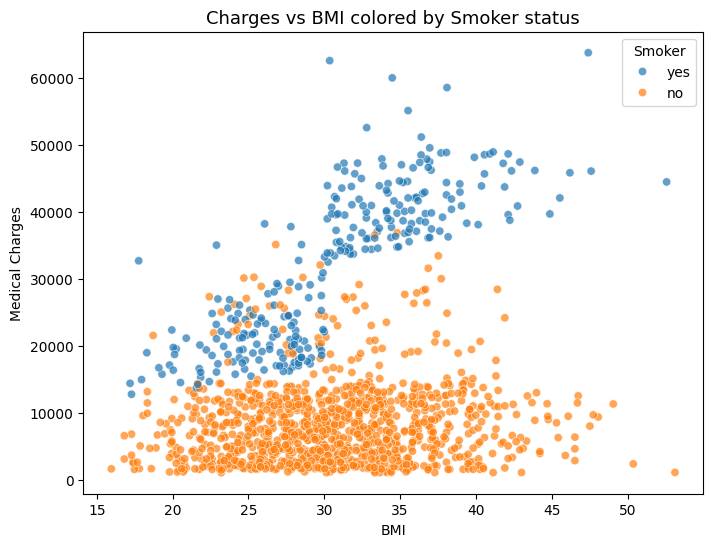

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.title('Charges vs BMI colored by Smoker status', fontsize=13)
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.legend(title='Smoker')
plt.show()

# smoker get higher charge and increase BMI it shows nonlinearity 


/tmp/ipykernel_80803/3218684705.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='region', y='charges', hue='smoker', estimator='mean', ci=None)


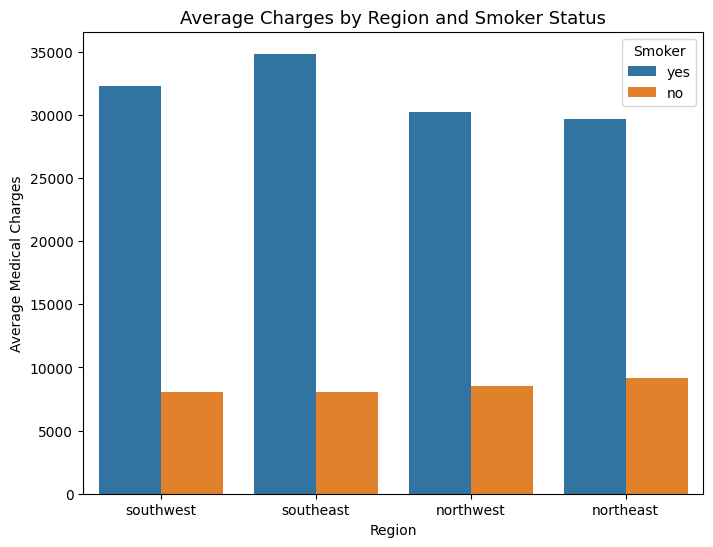

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='region', y='charges', hue='smoker', estimator='mean', ci=None)
plt.title('Average Charges by Region and Smoker Status', fontsize=13)
plt.ylabel('Average Medical Charges')
plt.xlabel('Region')
plt.legend(title='Smoker')
plt.show()



OneHotEncoder

In [32]:
# Copy the dataframe to avoid overwriting
df_corr = df.copy()

# Encode smoker as binary (yes = 1, no = 0)
df_corr['smoker_encoded'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
numeric_corr = df_corr[['age', 'bmi', 'children', 'smoker_encoded', 'charges']]
corr_matrix = numeric_corr.corr()
corr_matrix


,age,bmi,children,smoker_encoded,charges
age,1.000000,0.109272,0.042469,-0.025019,0.299008
bmi,0.109272,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.012759,1.000000,0.007673,0.067998
smoker_encoded,-0.025019,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.198341,0.067998,0.787251,1.000000


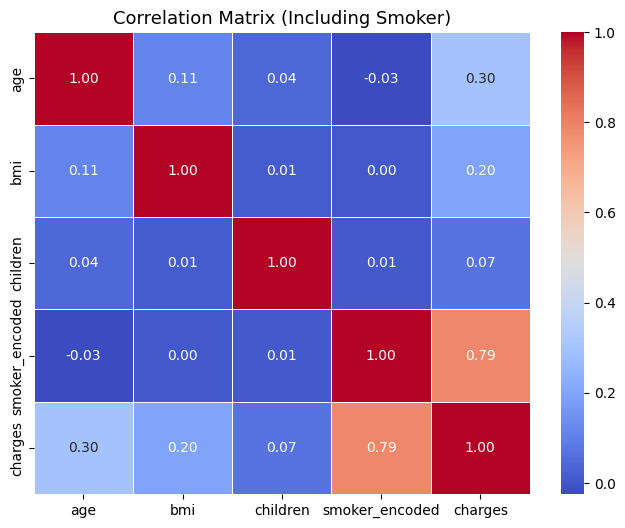

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Including Smoker)', fontsize=13)
plt.show()


## split into train/test

In [8]:
# Target feature 
y = df['charges']

# all other features just remove the target charger 
X = df.drop(columns=['charges'])

# Train-test split 0,2 0.8 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


## Preprocessing 

In [ ]:

categorical_cols = ['sex', 'smoker', 'region']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols), # 0-1 scaling
        ('cat', OneHotEncoder(drop='first'), categorical_cols) 
        # first drop means remove one feature and keep 2 
    ],
    remainder='drop'
)

## Build models

In [13]:
#Multiple Linear 
pipe_linear = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', LinearRegression())
])

#Polynomial Regression
pipe_poly = Pipeline(steps=[
    ('pre', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

# (c) Decision Tree Regression
# Decision trees do not require scaling or polynomial transformation, but we can keep encoding
pipe_tree = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=None))
])


## Train models

In [14]:
# Fit each model
pipe_linear.fit(X_train, y_train)
pipe_poly.fit(X_train, y_train)
pipe_tree.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

## Evaluation MSE + R2 + MEA

In [16]:
def evaluate_model(pipe, X_test, y_test, name="model"):
    preds = pipe.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    return {'model': name, 'MSE': mse, 'R2': r2, 'MAE': mae, 'y_true': y_test, 'y_pred': preds}

results = []
results.append(evaluate_model(pipe_linear, X_test, y_test, name='LinearRegression'))
results.append(evaluate_model(pipe_poly, X_test, y_test, name='PolynomialRegression_deg2'))
results.append(evaluate_model(pipe_tree, X_test, y_test, name='DecisionTree'))

summary = pd.DataFrame([{'model': r['model'], 'MSE': r['MSE'], 'R2': r['R2'], 'MAE': r['MAE']} for r in results])
print(summary.sort_values('MSE'))


                       model           MSE        R2          MAE
1  PolynomialRegression_deg2  2.071022e+07  0.866600  2729.133839
0           LinearRegression  3.359692e+07  0.783593  4181.194474
2               DecisionTree  4.079533e+07  0.737226  3114.152909


## Visualization 

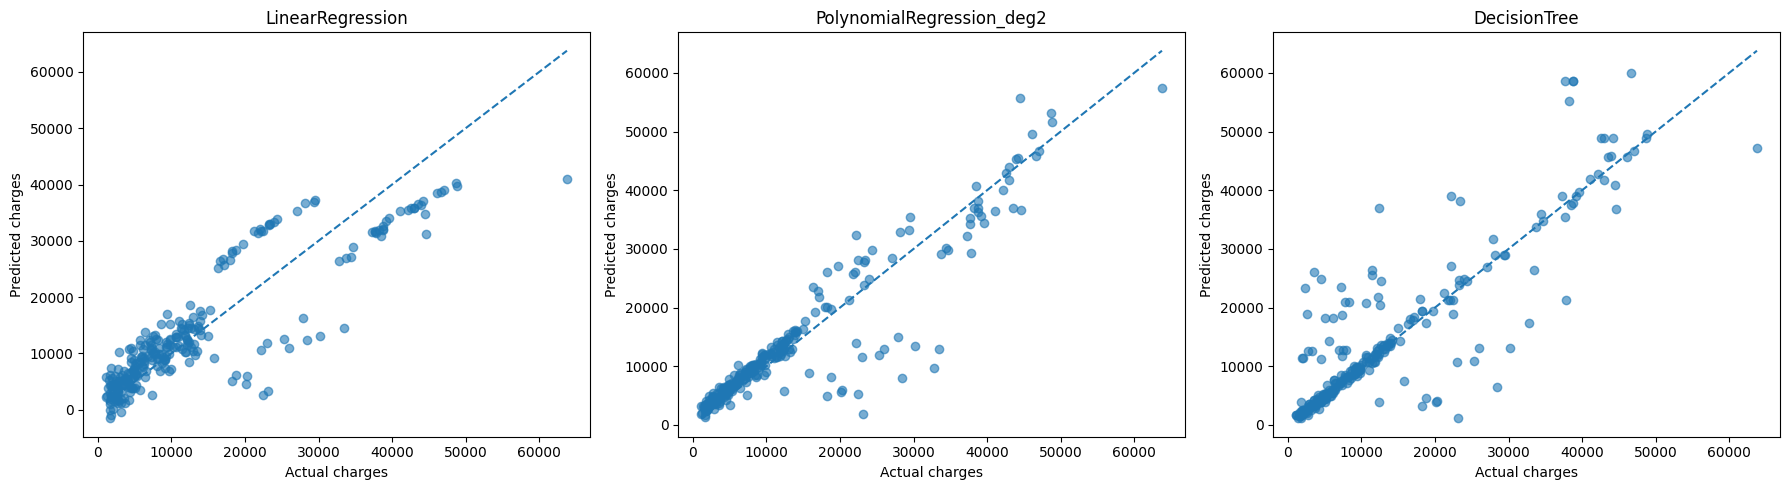

In [ ]:
# Plot true vs = for each model
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, r in zip(axes, results):
    ax.scatter(r['y_true'], r['y_pred'], alpha=0.6)
    ax.plot([r['y_true'].min(), r['y_true'].max()],
            [r['y_true'].min(), r['y_true'].max()],
            linestyle='--')
    ax.set_title(r['model'])
    ax.set_xlabel('Actual charges')
    ax.set_ylabel('Predicted charges')
plt.tight_layout()
plt.show()
